In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded!')

All libraries loaded!


In [20]:
df = pd.read_csv('Seasons_Stats.csv', index_col=0)
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Year range: {int(df["Year"].min())} - {int(df["Year"].max())}')
print(f'Unique players: {df["Player"].nunique()}')
df.head()

Loaded: 24691 rows, 52 columns
Year range: 1950 - 2017
Unique players: 3921


,Year,Player,Pos,Age,Tm,G,GS,MP,PER,TS%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1950.0,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,NaN,0.368,...,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1950.0,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,NaN,0.435,...,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,1950.0,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,NaN,0.394,...,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0
3,1950.0,Ed Bartels,F,24.0,TOT,15.0,NaN,NaN,NaN,0.312,...,0.559,NaN,NaN,NaN,20.0,NaN,NaN,NaN,29.0,63.0
4,1950.0,Ed Bartels,F,24.0,DNN,13.0,NaN,NaN,NaN,0.308,...,0.548,NaN,NaN,NaN,20.0,NaN,NaN,NaN,27.0,59.0


In [21]:
df = df[df['Year'] >= 1980].copy()
df = df.sort_values(['Player', 'Year', 'Tm'])
df = df.drop_duplicates(subset=['Player', 'Year'], keep='first')
df = df[df['G'] >= 20]

df['PPG']   = df['PTS'] / df['G']
df['RPG']   = df['TRB'] / df['G']
df['APG']   = df['AST'] / df['G']
df['SPG']   = df['STL'] / df['G']
df['BPG']   = df['BLK'] / df['G']
df['TOPG']  = df['TOV'] / df['G']
df['MPG']   = df['MP']  / df['G']
df['FPG']   = df['FG']  / df['G']
df['FAPG']  = df['FGA'] / df['G']
df['FTPG']  = df['FT']  / df['G']
df['FTAPG'] = df['FTA'] / df['G']
df['3PPG']  = df['3P']  / df['G']
df['3PAPG'] = df['3PA'] / df['G']

feature_cols = [
    'Age', 'G', 'MPG', 'PER', 'TS%', 'AST%', 'USG%',
    'OWS', 'DWS', 'WS', 'FPG', 'FAPG', 'FG%',
    '3PPG', '3PAPG', 'FTPG', 'FTAPG', 'FT%',
    'RPG', 'APG', 'SPG', 'BPG', 'TOPG', 'PPG'
]

df = df[['Player', 'Year'] + feature_cols].copy()
df[feature_cols] = df[feature_cols].fillna(0)

print(f'Cleaned dataset: {df.shape[0]} player-seasons')
df.head()

Cleaned dataset: 12898 player-seasons


,Player,Year,Age,G,MPG,PER,TS%,AST%,USG%,OWS,...,3PAPG,FTPG,FTAPG,FT%,RPG,APG,SPG,BPG,TOPG,PPG
8035,A.C. Green,1986.0,22.0,82.0,18.804878,11.8,0.564,4.2,14.7,1.4,...,0.073171,1.243902,2.036585,0.611,4.646341,0.658537,0.597561,0.597561,1.207317,6.353659
8420,A.C. Green,1987.0,23.0,79.0,28.354430,15.7,0.599,4.6,14.7,4.3,...,0.063291,2.784810,3.569620,0.780,7.784810,1.063291,0.886076,1.012658,1.291139,10.784810
8807,A.C. Green,1988.0,24.0,82.0,32.146341,14.5,0.581,4.5,14.7,4.5,...,0.024390,3.573171,4.621951,0.773,8.658537,1.134146,1.060976,0.548780,1.463415,11.426829
9242,A.C. Green,1989.0,25.0,82.0,30.609756,17.8,0.594,5.5,17.0,5.8,...,0.207317,3.439024,4.378049,0.786,9.012195,1.256098,1.146341,0.670732,1.451220,13.268293
9688,A.C. Green,1990.0,26.0,82.0,33.036585,14.7,0.548,4.6,17.1,4.4,...,0.560976,3.390244,4.512195,0.751,8.682927,1.097561,0.804878,0.609756,1.414634,12.939024


In [22]:
df = df.sort_values(['Player', 'Year']).reset_index(drop=True)

df['Next_Season_PPG'] = df.groupby('Player')['PPG'].shift(-1)
df['Next_Season_RPG'] = df.groupby('Player')['RPG'].shift(-1)
df['Next_Season_APG'] = df.groupby('Player')['APG'].shift(-1)
df['Next_Year']       = df.groupby('Player')['Year'].shift(-1)

df = df[df['Next_Year'] == df['Year'] + 1].copy()
df = df.drop(columns=['Next_Year'])
df = df.dropna(subset=['Next_Season_PPG', 'Next_Season_RPG', 'Next_Season_APG'])

print(f'Final dataset: {df.shape[0]} player-season pairs')
df[['Player','Year','PPG','RPG','APG','Next_Season_PPG','Next_Season_RPG','Next_Season_APG']].sort_values('PPG', ascending=False).head(10)

Final dataset: 9823 player-season pairs


,Player,Year,PPG,RPG,APG,Next_Season_PPG,Next_Season_RPG,Next_Season_APG
8639,Michael Jordan*,1987.0,37.085366,5.243902,4.597561,34.975610,5.475610,5.914634
7237,Kobe Bryant,2006.0,35.400000,5.312500,4.500000,31.558442,5.701299,5.363636
8640,Michael Jordan*,1988.0,34.975610,5.475610,5.914634,32.506173,8.049383,8.024691
8642,Michael Jordan*,1990.0,33.573171,6.890244,6.329268,31.463415,6.000000,5.524390
4434,George Gervin*,1980.0,33.141026,5.166667,2.589744,27.085366,5.109756,3.170732
276,Allen Iverson*,2006.0,33.013889,3.222222,7.388889,24.820000,3.040000,7.180000
8641,Michael Jordan*,1989.0,32.506173,8.049383,8.024691,33.573171,6.890244,6.329268
4436,George Gervin*,1982.0,32.291139,4.962025,2.367089,26.192308,4.576923,3.384615
12121,Tracy McGrady,2003.0,32.093333,6.506667,5.480000,28.029851,6.000000,5.522388
7016,Kevin Durant,2014.0,32.012346,7.382716,5.493827,25.407407,6.592593,4.074074


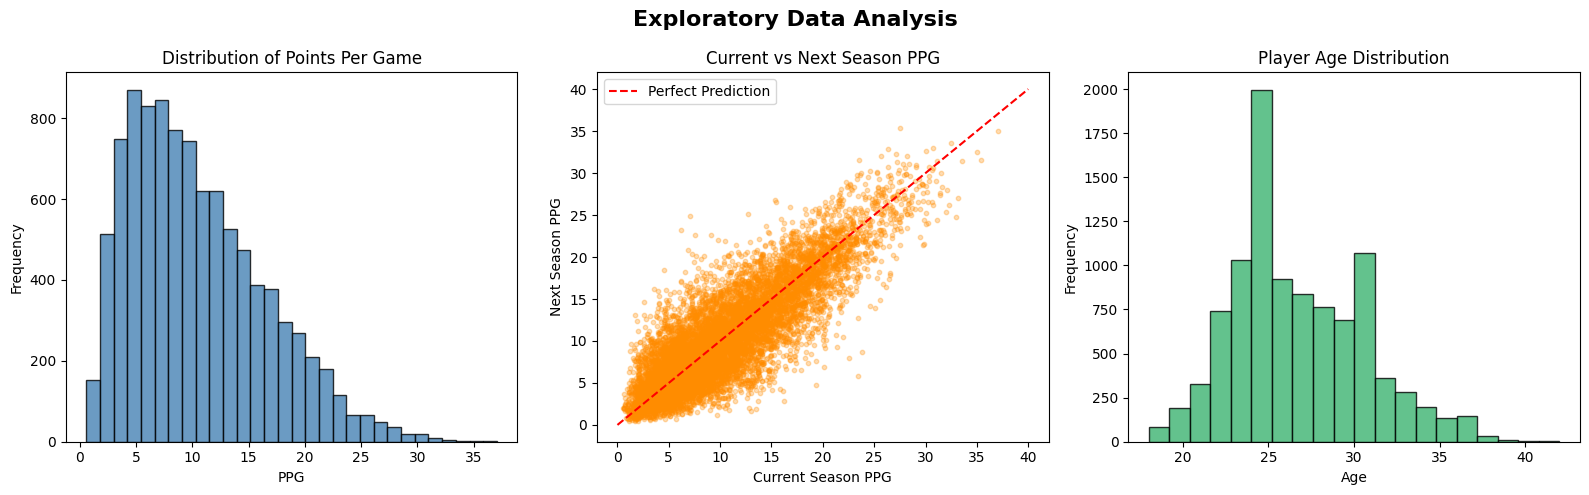

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

axes[0].hist(df['PPG'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Points Per Game')
axes[0].set_xlabel('PPG')
axes[0].set_ylabel('Frequency')

axes[1].scatter(df['PPG'], df['Next_Season_PPG'], alpha=0.3, color='darkorange', s=10)
axes[1].plot([0, 40], [0, 40], 'r--', label='Perfect Prediction')
axes[1].set_title('Current vs Next Season PPG')
axes[1].set_xlabel('Current Season PPG')
axes[1].set_ylabel('Next Season PPG')
axes[1].legend()

axes[2].hist(df['Age'], bins=20, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Player Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

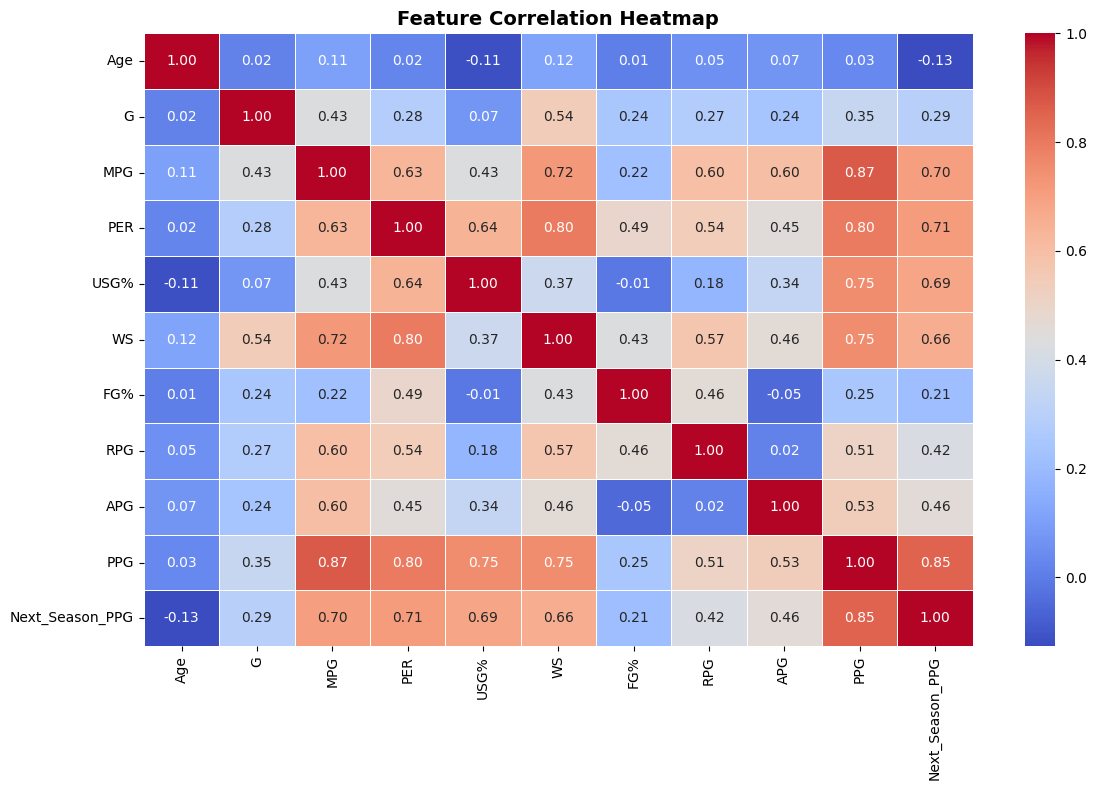

In [24]:
plt.figure(figsize=(12, 8))
corr_cols = ['Age','G','MPG','PER','USG%','WS','FG%','RPG','APG','PPG','Next_Season_PPG']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
X = df[feature_cols].values
y_ppg = df['Next_Season_PPG'].values
y_rpg = df['Next_Season_RPG'].values
y_apg = df['Next_Season_APG'].values


idx = np.arange(len(X))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

X_train, X_test         = X[idx_train], X[idx_test]
y_train, y_test         = y_ppg[idx_train], y_ppg[idx_test]
y_train_rpg, y_test_rpg = y_rpg[idx_train], y_rpg[idx_test]
y_train_apg, y_test_apg = y_apg[idx_train], y_apg[idx_test]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 7858
Testing samples  : 1965
Features         : 24


In [26]:
print('Training Linear Regression...')
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_preds = lr.predict(X_test_s)

lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)
print(f'MAE={lr_mae:.2f} ppg | RMSE={lr_rmse:.2f} ppg | R²={lr_r2:.4f}')

Training Linear Regression...
MAE=2.30 ppg | RMSE=2.98 ppg | R²=0.7625


In [27]:
print('Training Random Forest...')
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)
print(f'MAE={rf_mae:.2f} ppg | RMSE={rf_rmse:.2f} ppg | R²={rf_r2:.4f}')

Training Random Forest...
MAE=2.33 ppg | RMSE=3.03 ppg | R²=0.7554


In [28]:

print('Training RPG Model...')
rf_rpg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_rpg.fit(X_train, y_train_rpg)
rpg_preds = rf_rpg.predict(X_test)
rpg_mae = mean_absolute_error(y_test_rpg, rpg_preds)
rpg_r2  = r2_score(y_test_rpg, rpg_preds)
print(f'RPG → MAE={rpg_mae:.2f} | R²={rpg_r2:.4f}')


print('Training APG Model...')
rf_apg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_apg.fit(X_train, y_train_apg)
apg_preds = rf_apg.predict(X_test)
apg_mae = mean_absolute_error(y_test_apg, apg_preds)
apg_r2  = r2_score(y_test_apg, apg_preds)
print(f'APG → MAE={apg_mae:.2f} | R²={apg_r2:.4f}')

Training RPG Model...
RPG → MAE=0.92 | R²=0.7677
Training APG Model...
APG → MAE=0.59 | R²=0.8104


In [29]:
print('Training MLP Neural Network...')
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(X_train_s, y_train)
mlp_preds = mlp.predict(X_test_s)

mlp_mae  = mean_absolute_error(y_test, mlp_preds)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_preds))
mlp_r2   = r2_score(y_test, mlp_preds)
print(f'MAE={mlp_mae:.2f} ppg | RMSE={mlp_rmse:.2f} ppg | R²={mlp_r2:.4f}')

Training MLP Neural Network...
MAE=2.29 ppg | RMSE=2.98 ppg | R²=0.7629


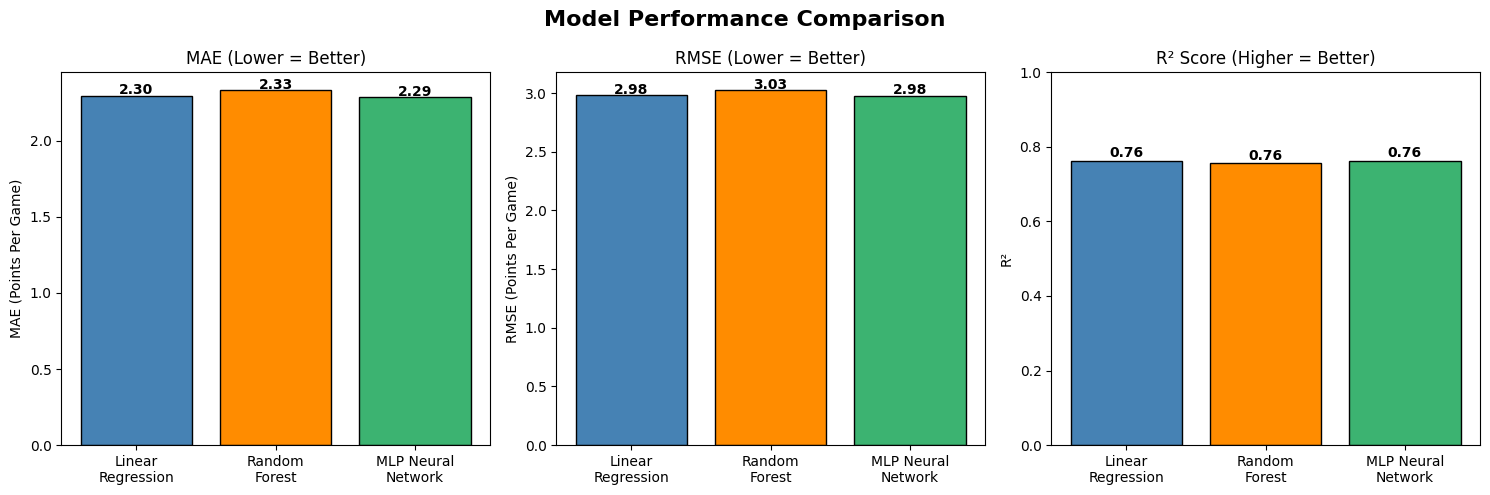

In [30]:
colors      = ['steelblue', 'darkorange', 'mediumseagreen']
model_names = ['Linear\nRegression', 'Random\nForest', 'MLP Neural\nNetwork']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

for ax, vals, title, ylabel in zip(
    axes,
    [[lr_mae,rf_mae,mlp_mae], [lr_rmse,rf_rmse,mlp_rmse], [lr_r2,rf_r2,mlp_r2]],
    ['MAE (Lower = Better)', 'RMSE (Lower = Better)', 'R² Score (Higher = Better)'],
    ['MAE (Points Per Game)', 'RMSE (Points Per Game)', 'R²']
):
    bars = ax.bar(model_names, vals, color=colors, edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if 'R²' in title:
        ax.set_ylim(0, 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

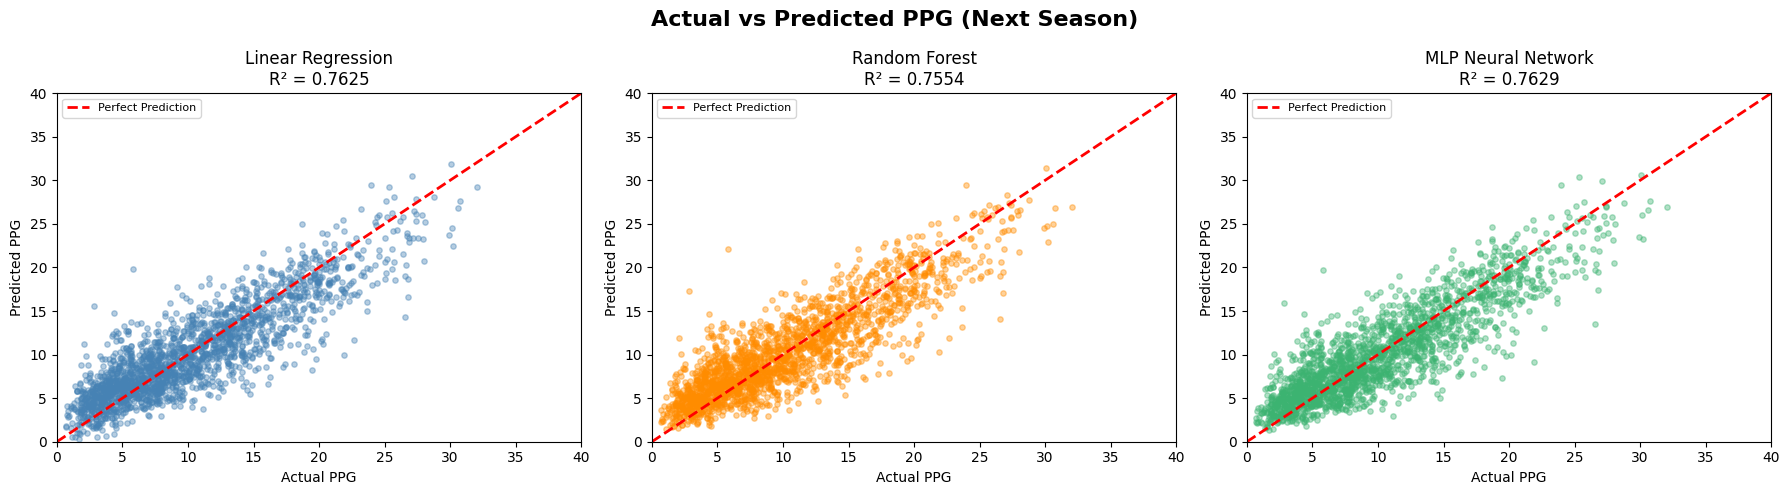

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Actual vs Predicted PPG (Next Season)', fontsize=16, fontweight='bold')

for i, (preds, title, r2) in enumerate(zip(
    [lr_preds, rf_preds, mlp_preds],
    ['Linear Regression', 'Random Forest', 'MLP Neural Network'],
    [lr_r2, rf_r2, mlp_r2]
)):
    axes[i].scatter(y_test, preds, alpha=0.4, color=colors[i], s=15)
    axes[i].plot([0, 40], [0, 40], 'r--', linewidth=2, label='Perfect Prediction')
    axes[i].set_title(f'{title}\nR² = {r2:.4f}')
    axes[i].set_xlabel('Actual PPG')
    axes[i].set_ylabel('Predicted PPG')
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(0, 40)
    axes[i].set_ylim(0, 40)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

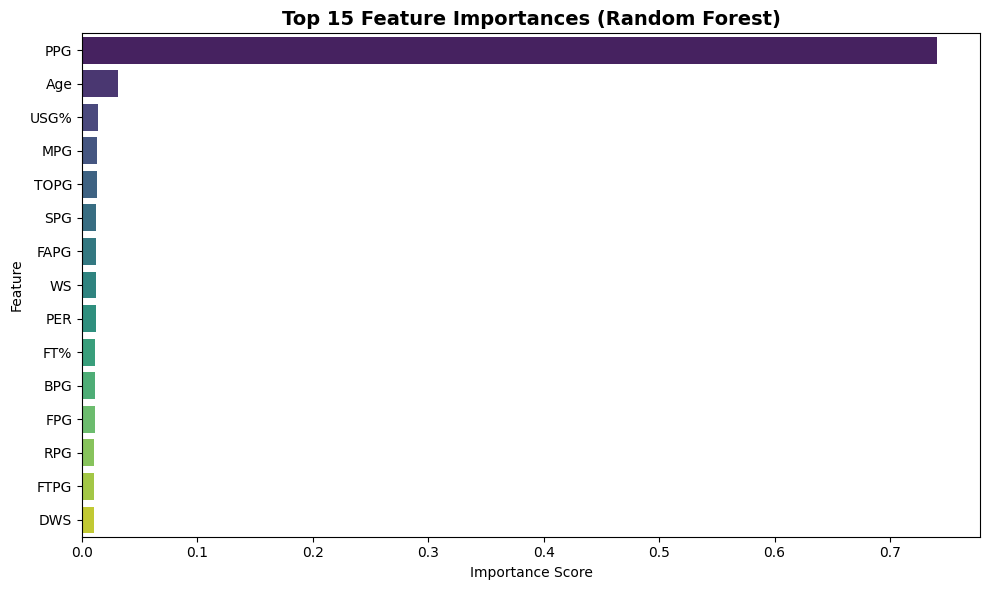

In [32]:
feat_imp = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

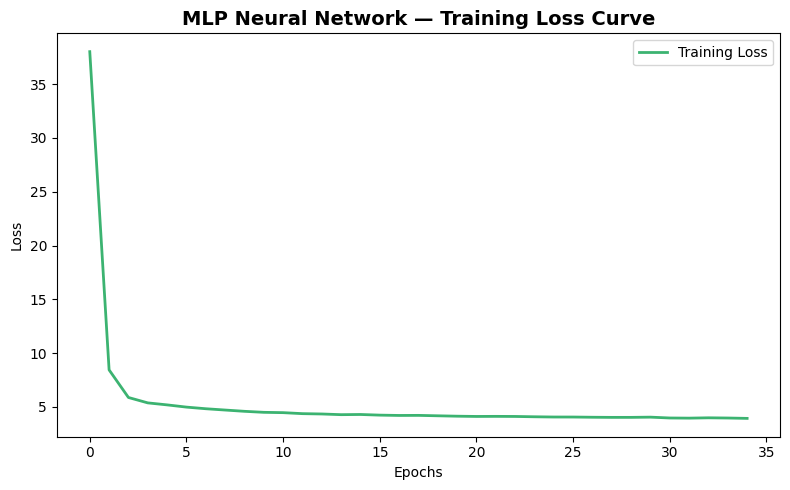

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color='mediumseagreen', linewidth=2, label='Training Loss')
plt.title('MLP Neural Network — Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
sample_out = df.iloc[idx_test][['Player', 'Year', 'PPG', 'Next_Season_PPG']].copy()
sample_out.columns = ['Player', 'Year', 'This_Season_PPG', 'Actual_Next_PPG']
sample_out['LR_Pred']  = lr_preds.round(1)
sample_out['RF_Pred']  = rf_preds.round(1)
sample_out['MLP_Pred'] = mlp_preds.round(1)

print('Sample Predictions — Players with 20+ PPG:')
print(sample_out[sample_out['This_Season_PPG'] >= 20]
      .sort_values('This_Season_PPG', ascending=False)
      .head(15).to_string(index=False))

print(f'\n{"="*55}')
print(f'         PLAYERPREDICT AI — COMPLETE')
print(f'{"="*55}')
print(f'Linear Regression  → MAE={lr_mae:.2f} | RMSE={lr_rmse:.2f} | R²={lr_r2:.4f}')
print(f'Random Forest      → MAE={rf_mae:.2f} | RMSE={rf_rmse:.2f} | R²={rf_r2:.4f}')
print(f'MLP Neural Network → MAE={mlp_mae:.2f} | RMSE={mlp_rmse:.2f} | R²={mlp_r2:.4f}')

Sample Predictions — Players with 20+ PPG:
            Player   Year  This_Season_PPG  Actual_Next_PPG  LR_Pred  RF_Pred  MLP_Pred
    George Gervin* 1980.0        33.141026        27.085366     30.5     28.3      29.9
   Michael Jordan* 1991.0        31.463415        30.050000     31.9     31.4      30.6
   Adrian Dantley* 1983.0        30.727273        30.607595     26.8     25.0      26.5
     Stephen Curry 2016.0        30.063291        25.303797     29.3     26.5      30.4
       Kobe Bryant 2003.0        30.012195        23.953846     29.5     29.4      29.4
Dominique Wilkins* 1993.0        29.873239        24.408163     25.8     26.0      26.4
   Michael Jordan* 1997.0        29.646341        28.743902     28.1     27.8      27.4
      Mark Aguirre 1984.0        29.493671        25.687500     28.1     27.2      27.5
Dominique Wilkins* 1987.0        29.037975        30.730769     27.6     26.9      27.6
   Carmelo Anthony 2013.0        28.656716        27.428571     26.1     25.7

In [35]:
def predict_player(name):
    matches = df[df['Player'].str.contains(name, case=False, na=False)]
    if matches.empty:
        print(f'Player "{name}" not found.')
        return

    row = matches.iloc[-1]
    X_input = np.array(row[feature_cols].values).reshape(1, -1)


    ppg_trees = np.array([tree.predict(X_input)[0] for tree in rf.estimators_])
    ppg_mean, ppg_std = ppg_trees.mean(), ppg_trees.std()


    rpg_trees = np.array([tree.predict(X_input)[0] for tree in rf_rpg.estimators_])
    rpg_mean, rpg_std = rpg_trees.mean(), rpg_trees.std()


    apg_trees = np.array([tree.predict(X_input)[0] for tree in rf_apg.estimators_])
    apg_mean, apg_std = apg_trees.mean(), apg_trees.std()

    print(f"\n🏀 PlayerPredict AI — {row['Player']} ({int(row['Year'])} Season)")
    print(f"  Predicted Next Season PPG: {ppg_mean:.1f} ± {ppg_std:.1f}")
    print(f"  Predicted Next Season RPG: {rpg_mean:.1f} ± {rpg_std:.1f}")
    print(f"  Predicted Next Season APG: {apg_mean:.1f} ± {apg_std:.1f}")


predict_player('LeBron')
predict_player('Kobe')
predict_player('Michael Jordan')


🏀 PlayerPredict AI — LeBron James (2016 Season)
  Predicted Next Season PPG: 25.9 ± 2.0
  Predicted Next Season RPG: 8.2 ± 0.9
  Predicted Next Season APG: 8.0 ± 1.2

🏀 PlayerPredict AI — Kobe Bryant (2015 Season)
  Predicted Next Season PPG: 17.3 ± 3.7
  Predicted Next Season RPG: 4.1 ± 1.4
  Predicted Next Season APG: 3.4 ± 1.2

🏀 PlayerPredict AI — Michael Jordan* (2002 Season)
  Predicted Next Season PPG: 19.0 ± 4.6
  Predicted Next Season RPG: 4.9 ± 1.6
  Predicted Next Season APG: 4.7 ± 1.2


In [36]:
!pip install gradio -q
import gradio as gr

def predict_player_gradio(name):
    matches = df[df['Player'].str.contains(name, case=False, na=False)]
    if matches.empty:
        return f'❌ Player "{name}" not found.\n\nTip: Try last name only (e.g. "James" for LeBron James)'

    row = matches.iloc[-1]
    X_input = np.array(row[feature_cols].values).reshape(1, -1)

    ppg_trees = np.array([tree.predict(X_input)[0] for tree in rf.estimators_])
    ppg_mean, ppg_std = ppg_trees.mean(), ppg_trees.std()

    rpg_trees = np.array([tree.predict(X_input)[0] for tree in rf_rpg.estimators_])
    rpg_mean, rpg_std = rpg_trees.mean(), rpg_trees.std()

    apg_trees = np.array([tree.predict(X_input)[0] for tree in rf_apg.estimators_])
    apg_mean, apg_std = apg_trees.mean(), apg_trees.std()

    next_year = int(row['Year']) + 1

    result = f"""  Player      :  {row['Player']}
  Base Season :  {int(row['Year'])}
  Predicting  :  {next_year} Season
  ───────────────────────────────────

  📊  Predicted Next Season Stats

  🏆  Points Per Game   (PPG)  :  {ppg_mean:.1f} ± {ppg_std:.1f}
  🔄  Rebounds Per Game (RPG)  :  {rpg_mean:.1f} ± {rpg_std:.1f}
  🎯  Assists Per Game  (APG)  :  {apg_mean:.1f} ± {apg_std:.1f}

  ───────────────────────────────────
  🤖  Model Information

  Algorithm    :  Random Forest (100 Trees)
  PPG Accuracy :  R² = {rf_r2:.2f}  |  MAE = {rf_mae:.2f}
  RPG Accuracy :  R² = {rpg_r2:.2f}  |  MAE = {rpg_mae:.2f}
  APG Accuracy :  R² = {apg_r2:.2f}  |  MAE = {apg_mae:.2f}

  ───────────────────────────────────
  ⚠️  Dataset covers 1980–2017 seasons only
  ±   represents prediction uncertainty"""
    return result

with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="orange",
        neutral_hue="slate",
        font=gr.themes.GoogleFont("Inter")
    ),
    css="""
        .gradio-container { max-width: 1000px !important; margin: auto !important; }
        footer { visibility: hidden !important; }

        /* Output box styling */
        #output-box textarea {
            background: linear-gradient(145deg, #0f172a, #1e293b) !important;
            border: 1px solid #e8871a !important;
            border-radius: 12px !important;
            color: #e2e8f0 !important;
            font-family: 'Courier New', monospace !important;
            font-size: 0.9em !important;
            line-height: 1.8 !important;
            padding: 20px !important;
        }

        /* Input box styling */
        #input-box textarea {
            background: #1e293b !important;
            border: 1px solid #334155 !important;
            border-radius: 10px !important;
            color: #e2e8f0 !important;
            font-size: 1em !important;
        }

        /* Submit button */
        #submit-btn {
            background: linear-gradient(90deg, #e8871a, #f5a623) !important;
            border: none !important;
            border-radius: 10px !important;
            font-size: 1.1em !important;
            font-weight: 700 !important;
            letter-spacing: 0.5px !important;
        }
    """
) as app:

    gr.HTML("""
        <div style='text-align:center; padding: 30px 0 15px 0;'>
            <h1 style='font-size:2.4em; font-weight:800; color:#e8871a; margin:0; letter-spacing:-1px;'>
                🏀 PlayerPredict AI
            </h1>
            <p style='color:#94a3b8; font-size:1em; margin-top:8px;'>
                NBA Next-Season Performance Predictor
            </p>
        </div>
        <hr style='border-color:#1e293b; margin-bottom:25px;'>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            name_input = gr.Textbox(
                placeholder="e.g. LeBron, Kobe, Durant, Curry...",
                label="🔍 Player Name",
                lines=1,
                elem_id="input-box"
            )
            submit_btn = gr.Button(
                "🏀 Predict Next Season",
                variant="primary",
                size="lg",
                elem_id="submit-btn"
            )
            gr.Examples(
                examples=[
                    ["LeBron"], ["Kobe"], ["Durant"],
                    ["Curry"], ["Jordan"], ["Shaq"],
                    ["Iverson"], ["Dirk"]
                ],
                inputs=name_input,
                label="⚡ Quick Examples"
            )

        with gr.Column(scale=2):
            output = gr.Textbox(
                label="📊 Prediction Output",
                lines=20,
                interactive=False,
                placeholder="Enter a player name and click Predict...",
                elem_id="output-box"
            )

    submit_btn.click(fn=predict_player_gradio, inputs=name_input, outputs=output)
    name_input.submit(fn=predict_player_gradio, inputs=name_input, outputs=output)

    gr.HTML("""
        <hr style='border-color:#1e293b; margin-top:20px;'>
        <p style='text-align:center; color:#475569; font-size:0.78em; padding:12px 0 5px 0;'>
            Built with Python · scikit-learn · Gradio &nbsp;|&nbsp;
            Dataset: Kaggle NBA Players Stats (1980–2017)
        </p>
    """)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://661489c056dcd2ae96.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
